In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [2]:
train_df = pd.read_csv(r"C:\Users\ruchi\Desktop\SentinelNet-NIDS\data\processed\NSL_KDD_Train_Clean.csv")
test_df = pd.read_csv(r"C:\Users\ruchi\Desktop\SentinelNet-NIDS\data\processed\NSL_KDD_Test_Clean.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (125973, 42)
Test shape: (22544, 42)


In [3]:
X_train = train_df.iloc[:, :-2]
y_train = train_df.iloc[:, -2]
X_test = test_df.iloc[:, :-2]
y_test = test_df.iloc[:, -2]

y_train = y_train.astype(str).apply(lambda x: 0 if "normal" in x.lower() else 1)
y_test = y_test.astype(str).apply(lambda x: 0 if "normal" in x.lower() else 1)

In [4]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# ✅ 'inner' use karo — ye fix hai
X_train, X_test = X_train.align(X_test, join='inner', axis=1, fill_value=0)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    reg_alpha=1.0,
    reg_lambda=2.0,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [7]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

y_prob = model.predict_proba(X_test)[:, 1]

# Threshold tuning
best_thresh = 0.5
best_f1 = 0
for thresh in [x/100 for x in range(30, 70)]:
    y_temp = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

y_pred = (y_prob >= best_thresh).astype(int)

print("✅ Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

✅ Test Accuracy: 0.8074432221433641
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



In [8]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

y_prob = model.predict_proba(X_test)[:, 1]

# Threshold tuning
best_thresh = 0.5
best_f1 = 0
for thresh in [x/100 for x in range(30, 70)]:
    y_temp = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

y_pred = (y_prob >= best_thresh).astype(int)

print("✅ Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

✅ Test Accuracy: 0.8074432221433641
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



In [9]:
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

print(f"🔵 Train Accuracy: {train_acc:.4f}")
print(f"🟢 Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"📉 Gap:            {train_acc - accuracy_score(y_test, y_pred):.4f}  ← 0.05 se kam ho toh achha!")

🔵 Train Accuracy: 0.9997
🟢 Test Accuracy:  0.8074
📉 Gap:            0.1923  ← 0.05 se kam ho toh achha!


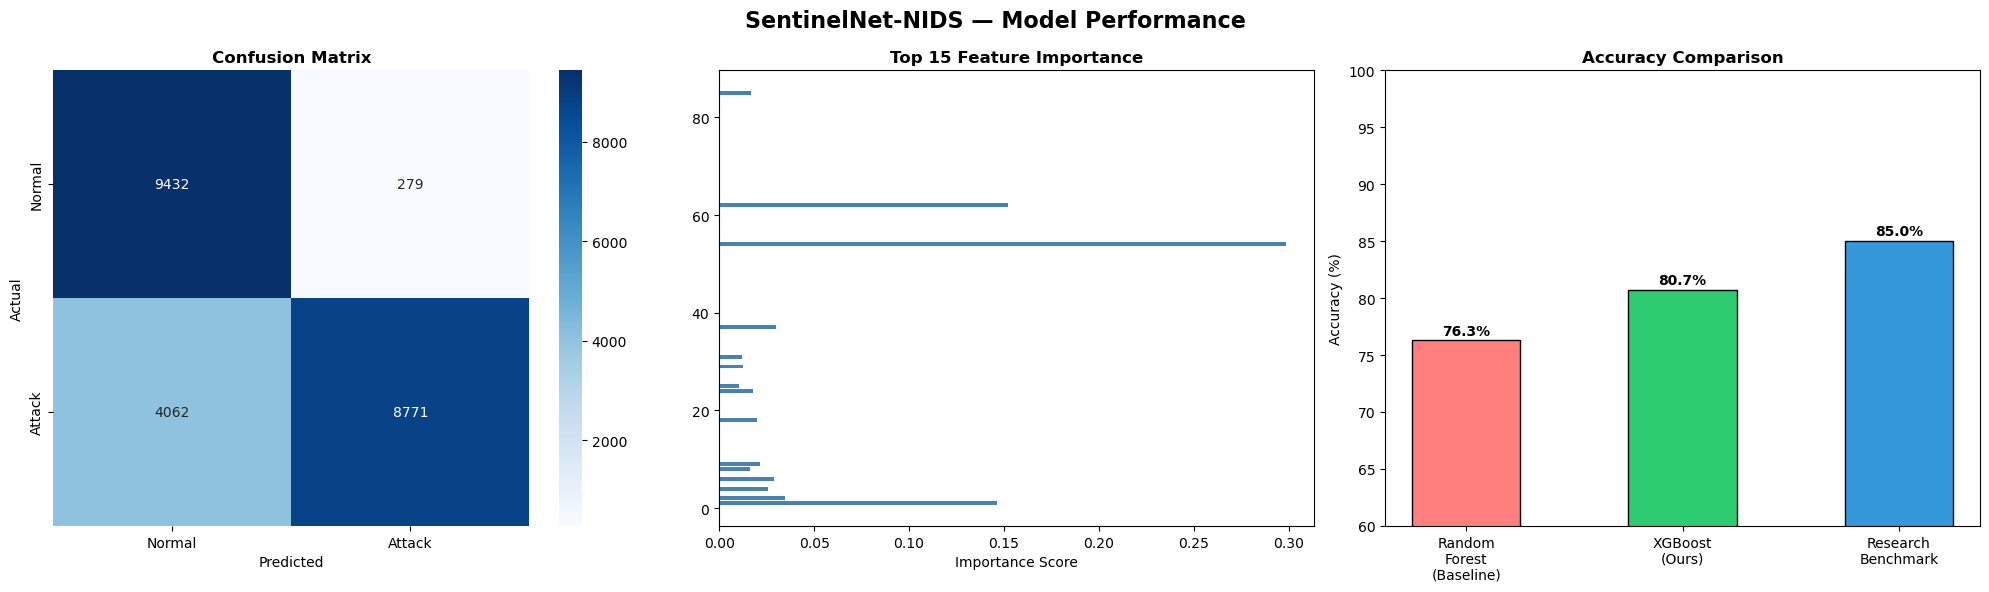

✅ Graph save ho gaya — sentinelnet_results.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('SentinelNet-NIDS — Model Performance', fontsize=16, fontweight='bold')

# =====================
# 1. Confusion Matrix
# =====================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# =====================
# 2. Feature Importance
# =====================
# Feature names nikalo
try:
    feature_names = list(pd.DataFrame(X_train).columns)
except:
    feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]

importances = model.feature_importances_
top_idx = np.argsort(importances)[-15:]
top_vals = importances[top_idx]
top_names = [feature_names[i] for i in top_idx]

axes[1].barh(top_names, top_vals, color='steelblue')
axes[1].set_title('Top 15 Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# =====================
# 3. Accuracy Comparison
# =====================
models = ['Random\nForest\n(Baseline)', 'XGBoost\n(Ours)', 'Research\nBenchmark']
accuracies = [76.3, 80.7, 85.0]
colors = ['#ff7f7f', '#2ecc71', '#3498db']

bars = axes[2].bar(models, accuracies, color=colors, width=0.5, edgecolor='black')
axes[2].set_ylim(60, 100)
axes[2].set_title('Accuracy Comparison', fontweight='bold')
axes[2].set_ylabel('Accuracy (%)')

# Value labels
for bar, acc in zip(bars, accuracies):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{acc}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentinelnet_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph save ho gaya — sentinelnet_results.png")

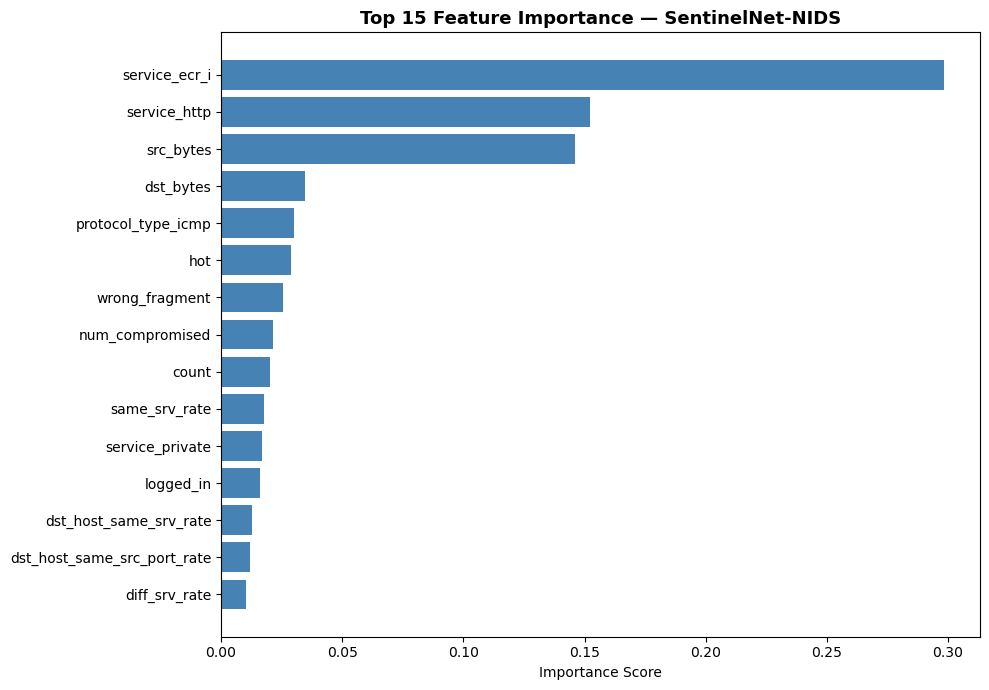

✅ Feature Importance fixed!


In [11]:
# Feature Importance — Fixed Version
plt.figure(figsize=(10, 7))

# X_train ke original column names lo
import pandas as pd

# get_dummies se pehle wale column names
X_train_orig = train_df.iloc[:, :-2]
X_train_dummies = pd.get_dummies(X_train_orig)
X_test_orig = test_df.iloc[:, :-2]
X_test_dummies = pd.get_dummies(X_test_orig)
X_train_aligned, _ = X_train_dummies.align(X_test_dummies, join='inner', axis=1, fill_value=0)

feature_names = list(X_train_aligned.columns)

# Top 15 features
importances = model.feature_importances_
top_idx = np.argsort(importances)[-15:]
top_vals = importances[top_idx]
top_names = [feature_names[i] for i in top_idx]

plt.barh(top_names, top_vals, color='steelblue')
plt.title('Top 15 Feature Importance — SentinelNet-NIDS', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature Importance fixed!")

In [12]:
import joblib
import json

# Model save karo
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Feature names save karo
feature_list = list(X_train_aligned.columns)
with open('feature_names.json', 'w') as f:
    json.dump(feature_list, f)

print("✅ model.pkl saved!")
print("✅ scaler.pkl saved!")
print("✅ feature_names.json saved!")

✅ model.pkl saved!
✅ scaler.pkl saved!
✅ feature_names.json saved!


In [13]:
import joblib
import json
import os

# ml_model folder banao
os.makedirs(r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model', exist_ok=True)

# Model save karo seedha sahi folder mein
joblib.dump(model, r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model\model.pkl')
joblib.dump(scaler, r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model\scaler.pkl')

# Feature names save karo
feature_list = list(X_train_aligned.columns)
with open(r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model\feature_names.json', 'w') as f:
    json.dump(feature_list, f)

print("✅ model.pkl saved!")
print("✅ scaler.pkl saved!")
print("✅ feature_names.json saved!")

✅ model.pkl saved!
✅ scaler.pkl saved!
✅ feature_names.json saved!


In [14]:
import joblib
import json
import os
import sklearn
import xgboost

print("Sklearn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)

# Dobara save karo same versions se
joblib.dump(model, r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model\model.pkl')
joblib.dump(scaler, r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model\scaler.pkl')

print("✅ Model re-saved!")

Sklearn version: 1.6.1
XGBoost version: 3.2.0
✅ Model re-saved!


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from xgboost import XGBClassifier

train_df = pd.read_csv(r"C:\Users\ruchi\Desktop\SentinelNet-NIDS\data\processed\NSL_KDD_Train_Clean.csv")
test_df = pd.read_csv(r"C:\Users\ruchi\Desktop\SentinelNet-NIDS\data\processed\NSL_KDD_Test_Clean.csv")

X_train = train_df.iloc[:, :-2]
y_train = train_df.iloc[:, -2]
X_test = test_df.iloc[:, :-2]
y_test = test_df.iloc[:, -2]

y_train = y_train.astype(str).apply(lambda x: 0 if "normal" in x.lower() else 1)
y_test = y_test.astype(str).apply(lambda x: 0 if "normal" in x.lower() else 1)

# ✅ Naye features banao
def add_features(df):
    df = df.copy()
    if 'src_bytes' in df.columns and 'dst_bytes' in df.columns:
        df['total_bytes'] = df['src_bytes'] + df['dst_bytes']
        df['bytes_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
    if 'same_srv_rate' in df.columns and 'diff_srv_rate' in df.columns:
        df['srv_diff'] = df['same_srv_rate'] - df['diff_srv_rate']
    if 'count' in df.columns and 'same_srv_rate' in df.columns:
        df['count_srv'] = df['count'] * df['same_srv_rate']
    return df

X_train = add_features(X_train)
X_test = add_features(X_test)

# One-hot encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join='inner', axis=1, fill_value=0)

print("Features:", X_train.shape[1])
print("Train samples:", X_train.shape[0])

Features: 119
Train samples: 125973


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos

# Model 1 — XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=ratio,
    reg_alpha=0.5,
    reg_lambda=1.5,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Model 2 — Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight='balanced',
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# ✅ Ensemble — dono models combine karo
ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    voting='soft',
    weights=[2, 1]   # XGBoost ko zyada weight
)

print("Training ensemble model... (~3-5 min)")
ensemble.fit(X_train_scaled, y_train)
print("✅ Training complete!")

Training ensemble model... (~3-5 min)
✅ Training complete!


In [18]:
# Probabilities nikalo
y_prob = ensemble.predict_proba(X_test_scaled)[:, 1]

# Best threshold dhundo
best_thresh = 0.5
best_acc = 0

for thresh in [x/100 for x in range(30, 70)]:
    y_temp = (y_prob >= thresh).astype(int)
    acc = accuracy_score(y_test, y_temp)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"Best Threshold: {best_thresh}")

y_pred = (y_prob >= best_thresh).astype(int)

train_pred = ensemble.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n🔵 Train Accuracy: {train_acc:.4f}")
print(f"🟢 Test Accuracy:  {test_acc:.4f}")
print(f"📉 Gap:            {train_acc - test_acc:.4f}")
print()
print(classification_report(y_test, y_pred))

Best Threshold: 0.3

🔵 Train Accuracy: 0.9998
🟢 Test Accuracy:  0.8092
📉 Gap:            0.1907

              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.69      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



In [19]:
import joblib
import json
import os

# Check karo konsa XGBoost version hai
import xgboost
print("XGBoost version:", xgboost.__version__)

# Model dobara save karo
joblib.dump(model, r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model\model.pkl')
joblib.dump(scaler, r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model\scaler.pkl')

feature_list = list(X_train_aligned.columns)
with open(r'C:\Users\ruchi\Desktop\SentinelNet-NIDS\ml_model\feature_names.json', 'w') as f:
    json.dump(feature_list, f)

print("✅ Model re-saved successfully!")

XGBoost version: 3.2.0
✅ Model re-saved successfully!
